###### Carleton School of Information Technology
### ITEC 5920 – Applied Deep Learning
### Winter 2026
### Instructor: Dr. Marzieh Amini
### Prepared by: Aziz Al-Najjar

Acknowledgment:

1. https://towardsdatascience.com/introduction-to-linear-regression-in-python-c12a072bedf0

2. https://machinelearningmastery.com/linear-regression-for-machine-learning/

3. https://github.com/dataprofessor/code/blob/master/python/linear_regression.ipynb

## Linear Regression 

In this tutorial you will discover how to implement simple linear regressions with the Python from scratch and how to implement multiple linear regression using scikit-learn library

Linear regression assumes a linear relationship between the input (independent x) and the target (predicted y) features and fits a straight line through data depending on the relationship between x and y. 

There are two types of linear regression: 

#### 1- Simple Linear Regression: only one input (x) feature:

    ŷ=β₀+β₁x ... (1)
      ŷ is the predicted value of y for a given x
      β₀ is called the intercept, where x= 0
      β₁ is the coefficient of the input feature x, and it’s the slope of the line.
     For simple linear regression, the job is to estimate best values for β₀ and β₁ using the dataset.

#### 2- Multiple Linear Regression: many input features, x = (x₁, x₂,… xₙ) whereby n is the number of predictor features.

    ŷ=β₀+β₁x₁+β₂x₂+…+βₙxₙ
      ŷ is the predicted value of y for a given x. 
      β₀, β₁, β₂ and βₙ are the regression coefficients, where n is the number of input features.

For both types, our goal is to find statistically significant values of the parameters that minimise the difference between ŷ and y to have the line of best fit.

## 1- Simple Linear Regression From Scratch

To find β₀ and β₁ in eq (1), we will use the OLS (Ordinary Least Squares) method, where: 

β₁ = Cov(X, Y) / Var(X)

β₀ = Ȳ - β₁ * X̄ 

where X̄ is the mean of X values and Ȳ is the mean of Y values.


### We will start by loading the necessary libraries 

In [38]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import datasets

#### Next step is to load the dataset. 
We are going to use the Boston house prices dataset which is available from Scikit-learn 



In [39]:
data = datasets.load_boston()

This dataset has 13 features that affect the median value of the house in Boston. 

In [40]:
print(data.feature_names)

['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']


For the simple linear regression model, we will use *LSTAT* as the *input x* *feature*, and the median value (MEDV) as the *target y*

In [41]:
X = data.data[:,12] # 12 is the LSTAT column
y = data.target # target is the MEDV

print('x shape: ',X.shape)
print('y shape: ',y.shape)

x shape:  (506,)
y shape:  (506,)


#### Next is to calculate β₀ and β₁ using the OLS method

In [42]:
# Calculate the mean of X and y
xmean = np.mean(X)
ymean = np.mean(y)

# Calculate the terms needed for the numator and denominator of B1
xycov = (X - xmean) * (y - ymean)
xvar = (X - xmean)**2

# Calculate B1 and B0
B1 = xycov.sum() / xvar.sum()
B0 = ymean - (B1 * xmean)
print(f'B0 = {B0}')
print(f'B1 = {B1}')

B0 = 34.5538408793831
B1 = -0.9500493537579907


Great, we now have an estimate for B0 and B1! Our model can be written as ŷ = 34.55-0.95X, and we can make predictions:

In [43]:
ypred = B0 + B1 * X

Lets observe our first 5 predictions and the actual values

In [44]:
print('predictions:', ypred[:5])
print('Actual: ',y[:5])

predictions: [29.8225951  25.87038979 30.72514198 31.76069578 29.49007782]
Actual:  [24.  21.6 34.7 33.4 36.2]


Let’s plot our prediction ypred against the actual values of y, to get a better visual understanding of our model.

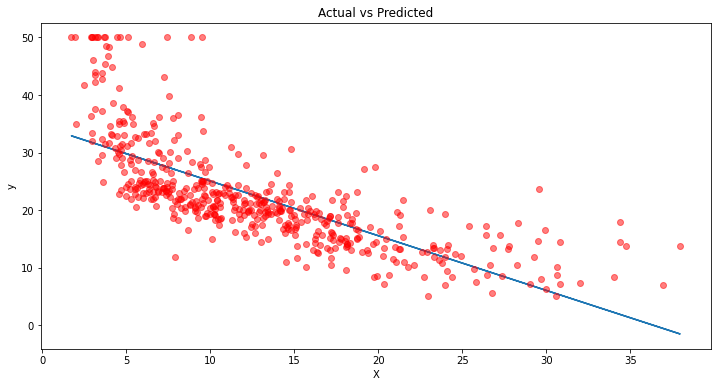

In [45]:
# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(X,ypred)     # regression line
plt.plot(X, y, 'ro', alpha = 0.5)   # scatter plot showing actual data
plt.title('Actual vs Predicted')
plt.xlabel('X')
plt.ylabel('y')

plt.show()

We can see from this graph that there is a negative linear relationship between X and y. Using our model, we can predict y from any values of X! 

## 2- Multiple Linear Regression using scikit-learn
Now we will try to solve the same problem, but instead, we will use all 13 features.

We will start by loading the linear regression model from scikit learn

In [46]:
from sklearn.linear_model import LinearRegression

#### Next step is to load the dataset. 

In [47]:
data = datasets.load_boston()

In [48]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.DataFrame(data.target, columns=["MEDV"])
print('x shape: ',X.shape)
print('y shape: ',y.shape)

x shape:  (506, 13)
y shape:  (506, 1)


In [49]:
print('x shape: ',X.shape)
print('y shape: ',y.shape)

x shape:  (506, 13)
y shape:  (506, 1)


#### Next step is to initialize an instance of the Linear regression model then fit the model instance to the data


In [50]:
# Initialise and fit model
lm = LinearRegression()
model = lm.fit(X, y)

Here, there is no need to calculate the intercept and coefficients ourselves

– we just have to call .intercept_ for B0, and .coef_ for an array with our coefficients:

In [51]:
print(f'b0 = {model.intercept_}')
print(f'betas = {model.coef_}')

b0 = [36.45948839]
betas = [[-1.08011358e-01  4.64204584e-02  2.05586264e-02  2.68673382e+00
  -1.77666112e+01  3.80986521e+00  6.92224640e-04 -1.47556685e+00
   3.06049479e-01 -1.23345939e-02 -9.52747232e-01  9.31168327e-03
  -5.24758378e-01]]


Since we are using the 13 features, we will have 13 different coefficients that will help in the prediction

We can predict values by simply using .predict():

In [52]:
preds = model.predict(X)

Lets observe our first 5 predictions and the actual values

In [53]:
print('predictions:', preds[:5])
print('Actual: ',y[:5])

predictions: [[30.00384338]
 [25.02556238]
 [30.56759672]
 [28.60703649]
 [27.94352423]]
Actual:     MEDV
0  24.0
1  21.6
2  34.7
3  33.4
4  36.2


$R^{2}$ is a measure of the goodness of fit of a model. In regression, the $R^{2}$ coefficient of determination is a statistical measure of how well the regression predictions approximate the real data points. An $R^{2}$ of 1 indicates that the regression predictions perfectly fit the data. We can also calculate the $R^{2}$ score using the model.score function from sklearn. 

In [54]:
R2 = model.score(X,y)
print(f'R2 = {R2}')

R2 = 0.7406426641094094


We can also calculate the mean squared error using sklearn

In [55]:
from sklearn.metrics import mean_squared_error
print('MSE = ', mean_squared_error(y,preds))

MSE =  21.894831181729206
